# Problem Type : Classification

# Task : Predict Product Purchase

# **Step 1: Import Required Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, roc_curve, auc

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# **Step 2: Load Dataset**

In [2]:
df = pd.read_csv('/content/Social Network Ads Dataset.csv')

print(df.head())

print("\nShape:", df.shape)

    User ID  Gender  Age  EstimatedSalary  Purchased
0  15624510    Male   19            19000          0
1  15810944    Male   35            20000          0
2  15668575  Female   26            43000          0
3  15603246  Female   27            57000          0
4  15804002    Male   19            76000          0

Shape: (400, 5)


# **Step 3: Basic Information**

In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB
None


In [8]:
print("\nMissing Values:")
df.isnull().sum()


Missing Values:


,0
User ID,0
Gender,0
Age,0
EstimatedSalary,0
Purchased,0


In [9]:
print("\nStatistical Summary:")
df.describe()


Statistical Summary:


,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


# **Step 4: Drop Unnecessary Column**
**Why?**

User ID has no impact on customer purchasing behavior.

In [10]:
df.drop("User ID", axis=1, inplace=True)

df.head()

,Gender,Age,EstimatedSalary,Purchased
0,Male,19,19000,0
1,Male,35,20000,0
2,Female,26,43000,0
3,Female,27,57000,0
4,Male,19,76000,0


# **Step 5: Encode Gender Column**
**Male = 1**

**Female = 0**

In [11]:
le = LabelEncoder()

df["Gender"] = le.fit_transform(df["Gender"])

df.head()

,Gender,Age,EstimatedSalary,Purchased
0,1,19,19000,0
1,1,35,20000,0
2,0,26,43000,0
3,0,27,57000,0
4,1,19,76000,0


# **Step 6: Target Distribution**

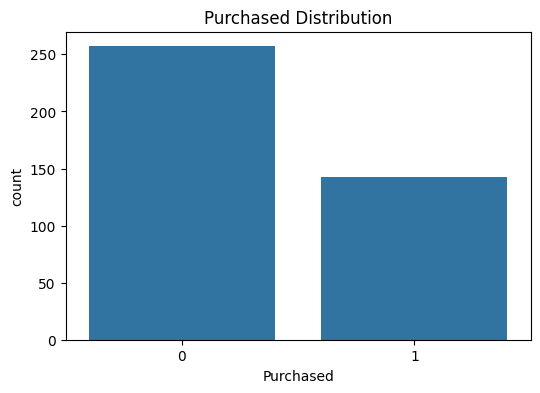

In [12]:
plt.figure(figsize=(6,4))

sns.countplot(x='Purchased', data=df)

plt.title("Purchased Distribution")
plt.show()

# **Step 7: Correlation Heatmap**

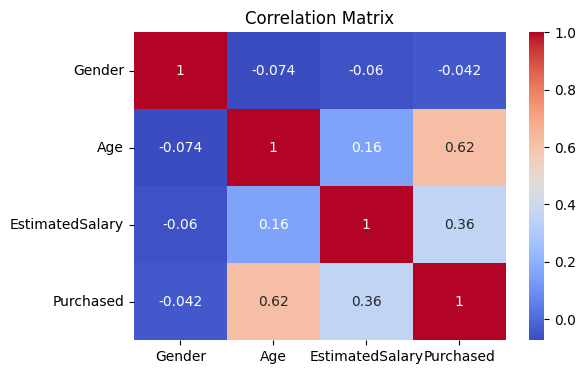

In [13]:
plt.figure(figsize=(6,4))

sns.heatmap(df.corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Matrix")
plt.show()

# **Step 8: Feature Selection**

In [14]:
X = df.drop("Purchased", axis=1)

y = df["Purchased"]

# **Step 9: Train Test Split**

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape : (320, 3)
Testing Shape : (80, 3)


# **Step 10: Feature Scaling**
**ANN works best with scaled data**

In [16]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

# **Step 11: Build ANN Model**

**Architecture**

```
Input Layer (3 Features)
       ↓
Dense (16 Neurons + ReLU)
       ↓
Dense (8 Neurons + ReLU)
       ↓
Dense (1 Neuron + Sigmoid)
```

In [17]:
ann = Sequential()

# Hidden Layer 1
ann.add(Dense(
    units=16,
    activation='relu',
    input_dim=X_train.shape[1]
))

# Hidden Layer 2
ann.add(Dense(
    units=8,
    activation='relu'
))

# Output Layer
ann.add(Dense(
    units=1,
    activation='sigmoid'
))

ann.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209 (836.00 B)

 Trainable params: 209 (836.00 B)

 Non-trainable params: 0 (0.00 B)

# **Step 12: Compile ANN**

In [18]:
ann.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# **Step 13: Train ANN**

In [19]:
history = ann.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.5938 - loss: 0.6929 - val_accuracy: 0.7500 - val_loss: 0.6333
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7070 - loss: 0.6486 - val_accuracy: 0.8281 - val_loss: 0.6028
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7852 - loss: 0.6138 - val_accuracy: 0.8594 - val_loss: 0.5770
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8242 - loss: 0.5830 - val_accuracy: 0.8750 - val_loss: 0.5501
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8516 - loss: 0.5536 - val_accuracy: 0.8750 - val_loss: 0.5254
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8477 - loss: 0.5258 - val_accuracy: 0.8750 - val_loss: 0.5003
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8633 - loss: 0.4989 - val_accuracy: 0.8906 - val_loss: 0.4740
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8711 - loss: 0.4714 - val_accuracy: 0.8906 - 

# **Step 14: Accuracy Graph**

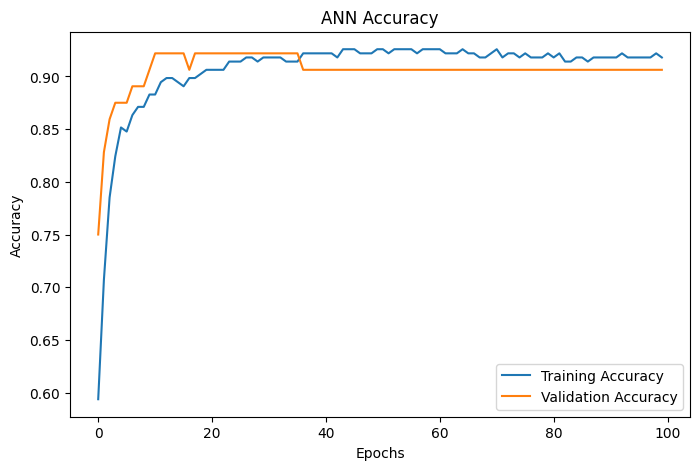

In [20]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'],
         label='Training Accuracy')

plt.plot(history.history['val_accuracy'],
         label='Validation Accuracy')

plt.title("ANN Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

# **Step 15: Loss Graph**

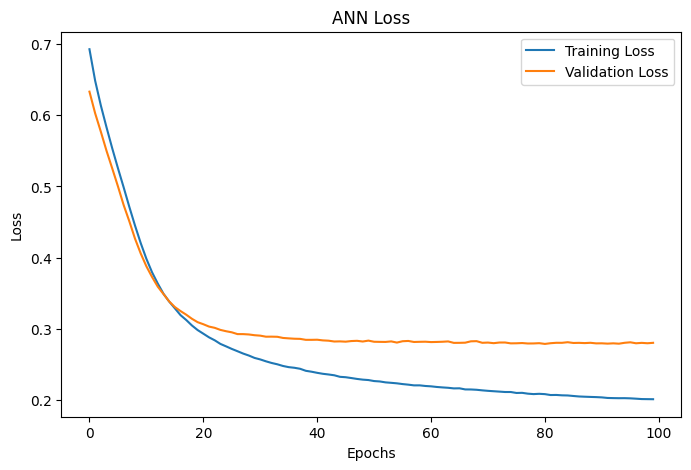

In [21]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'],
         label='Training Loss')

plt.plot(history.history['val_loss'],
         label='Validation Loss')

plt.title("ANN Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

# **Step 16: Prediction**

In [22]:
y_prob = ann.predict(X_test)

y_pred = (y_prob > 0.5).astype(int)

print(y_pred[:10])

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step
[[1]
 [1]
 [0]
 [1]
 [0]
 [0]
 [1]
 [0]
 [0]
 [0]]


# **Step 17: Confusion Matrix**

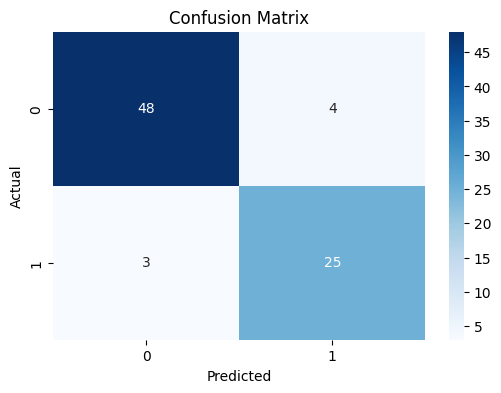

In [23]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

# **Step 18: Classification Report**

In [24]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.92      0.93        52
           1       0.86      0.89      0.88        28

    accuracy                           0.91        80
   macro avg       0.90      0.91      0.90        80
weighted avg       0.91      0.91      0.91        80



# **Step 19: Accuracy Score**

In [25]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", round(accuracy*100,2), "%")

Accuracy : 91.25 %


# **Step 20: ROC-AUC Curve**

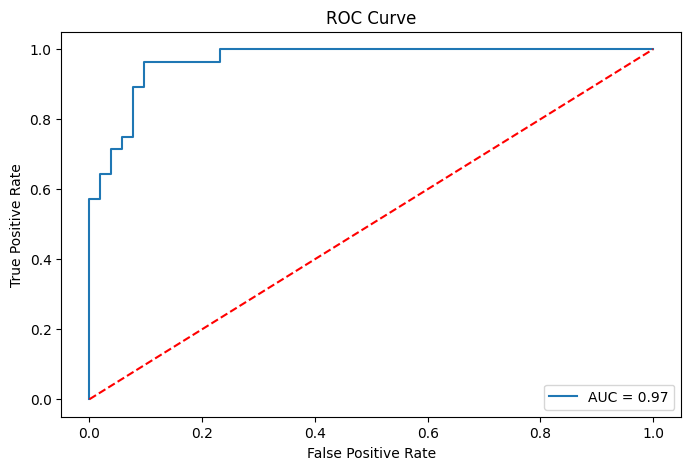

In [26]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,5))

plt.plot(fpr, tpr, label='AUC = %0.2f' % roc_auc)

plt.plot([0,1],[0,1],'r--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')

plt.legend()

plt.show()

# **Step 21: Predict New Customer**
**Example**
- Gender = Male
- Age = 40
- Salary = 90000

In [27]:
new_customer = pd.DataFrame({
    'Gender':[1],        # Male = 1
    'Age':[40],
    'EstimatedSalary':[90000]
})

new_customer_scaled = scaler.transform(new_customer)

prediction = ann.predict(new_customer_scaled)

print("Probability :", prediction[0][0])

if prediction[0][0] > 0.5:
    print("Customer Will Purchase")
else:
    print("Customer Will Not Purchase")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
Probability : 0.75936145
Customer Will Purchase
